# Market Positioning — Direct Price Comparison

This notebook analyses competitive positioning using **actual** observed
competitor prices (rather than model predictions). For each quote we know:

- Our own quoted price (`own_price`)
- What each of the 5 competitors quoted for the same risk (`comp_N_price`)

We compute a binary outcome per quote × competitor:
**are we cheaper?** — then aggregate this across segments to understand where
our pricing is competitive and where it isn't.

We also simulate the effect of applying a discount to understand how sensitive
our market position is to price changes.

In [1]:
import pandas as pd
import numpy as np
from plotnine import *

pd.set_option('display.max_columns', 100)

## 1. Load Data

In [2]:
df = pd.read_csv('../data/results_data.csv')

comp_price_cols = [c for c in df.columns if c.endswith('_price')]

print(f"Quotes: {len(df):,}")
print(f"Competitors: {len(comp_price_cols)}  ({comp_price_cols})")
df[['own_price', 'market_min', 'market_median', 'market_max']].describe().round(2)

Quotes: 1,000
Competitors: 6  (['comp_1_price', 'comp_2_price', 'comp_3_price', 'comp_4_price', 'comp_5_price', 'own_price'])


,own_price,market_min,market_median,market_max
count,1000.00,1000.00,1000.00,1000.00
mean,10403.05,8145.97,10409.70,13537.00
std,3494.23,2674.99,3381.75,4469.80
min,3443.26,2416.46,3255.97,4577.50
25%,7929.04,6127.14,8000.52,10212.88
50%,9710.41,7736.68,9828.88,12904.37
75%,12436.76,9774.60,12449.31,16262.84
max,24995.93,22746.62,25136.94,35131.19


## 2. Competitive Position — Per Competitor

For each competitor separately: in what fraction of quotes are we cheaper?

  competitor  pct_cheaper
comp_1_price        0.232
comp_2_price        0.466
comp_3_price        0.401
comp_4_price        0.813
comp_5_price        0.632
   own_price        0.000


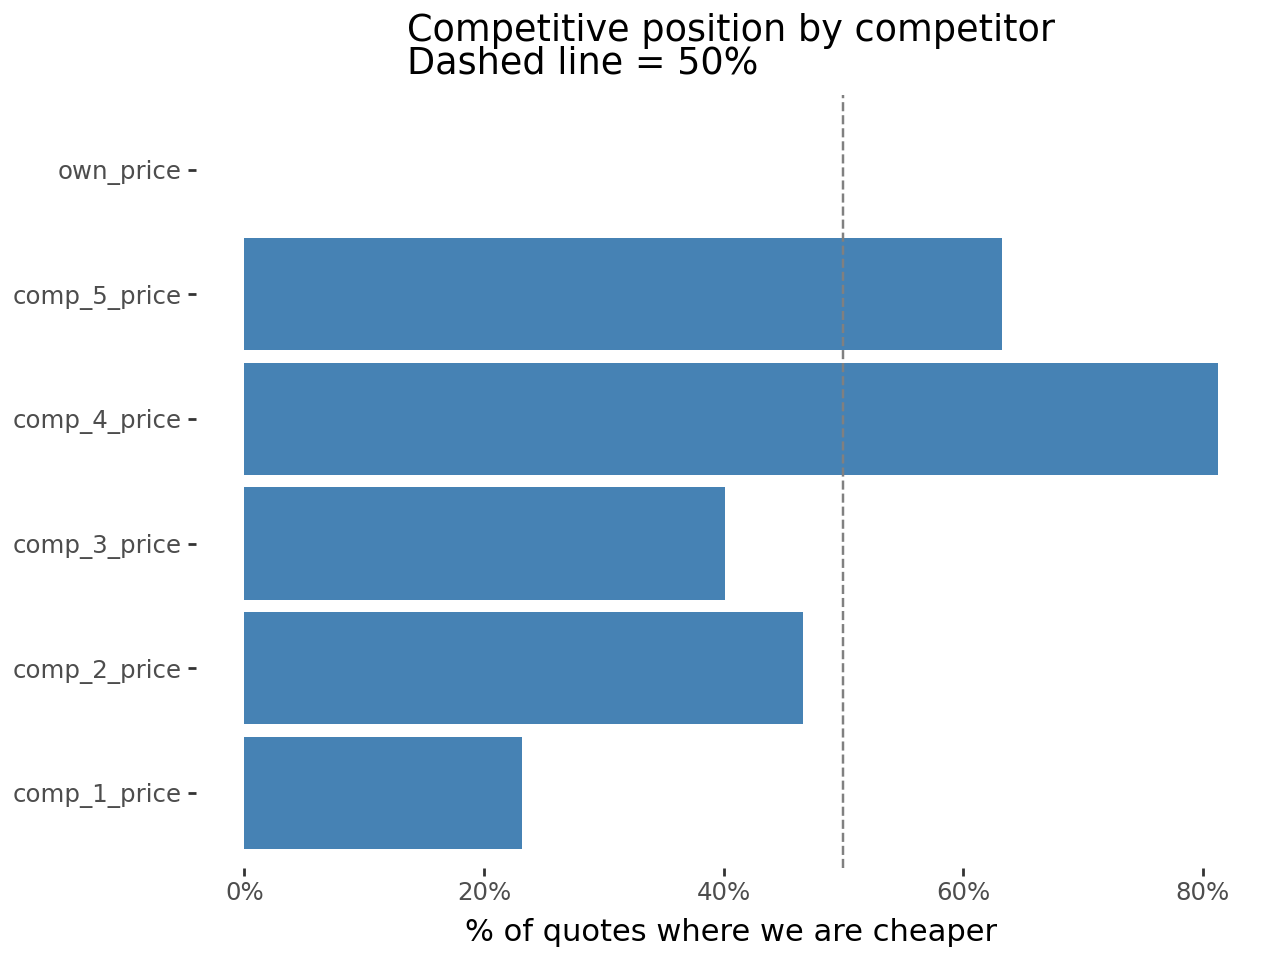

In [3]:
for col in comp_price_cols:
    df[f'cheaper_than_{col}'] = (df['own_price'] < df[col]).astype(int)

cheaper_cols = [f'cheaper_than_{c}' for c in comp_price_cols]
comp_summary = pd.DataFrame({
    'competitor': comp_price_cols,
    'pct_cheaper': [df[c].mean() for c in cheaper_cols],
})
print(comp_summary.to_string(index=False))

(ggplot(comp_summary, aes(x='competitor', y='pct_cheaper'))
 + geom_col(fill='steelblue')
 + geom_hline(yintercept=0.5, linetype='dashed', color='gray')
 + coord_flip()
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='', y='% of quotes where we are cheaper',
        title='Competitive position by competitor\nDashed line = 50%')
)

## 3. Segment Analysis

Break down competitive position by a key categorical feature to identify
where our pricing is systematically above or below market.

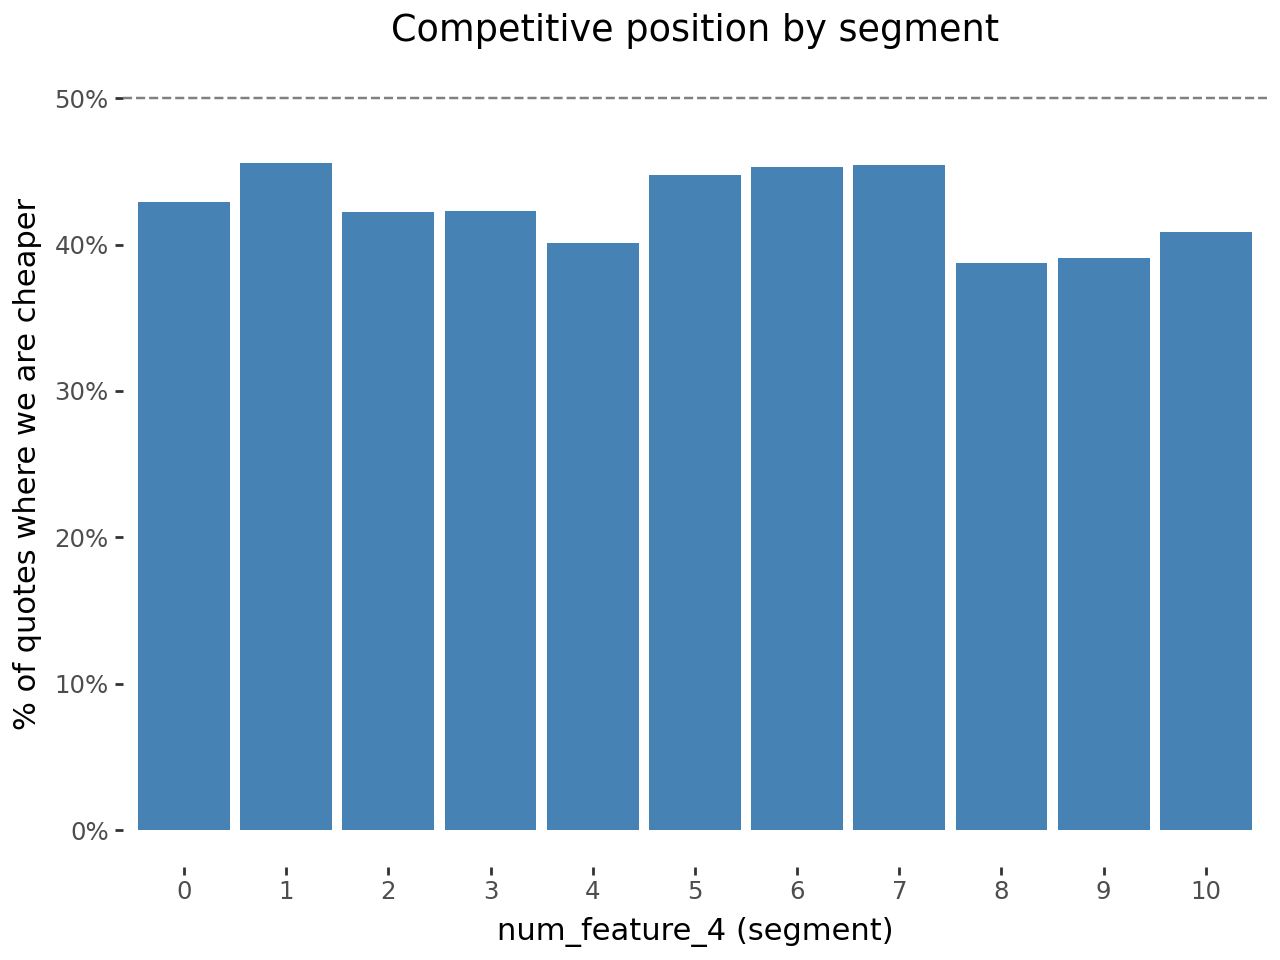

In [4]:
# Melt to long format: one row per quote × competitor comparison
df_long = pd.melt(
    df,
    id_vars=['quote_id', 'num_feature_4', 'cat_feature_1'],
    value_vars=cheaper_cols,
    var_name='competitor',
    value_name='is_cheaper',
)
df_long['competitor'] = df_long['competitor'].str.replace('cheaper_than_', '').str.replace('_price', '')

# Proportion cheaper by num_feature_4 (an ordinal numeric feature, 0-10)
seg = (
    df_long.groupby('num_feature_4')['is_cheaper']
    .mean()
    .reset_index()
    .rename(columns={'is_cheaper': 'pct_cheaper'})
)

(ggplot(seg, aes(x='factor(num_feature_4)', y='pct_cheaper'))
 + geom_col(fill='steelblue')
 + geom_hline(yintercept=0.5, linetype='dashed', color='gray')
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='num_feature_4 (segment)', y='% of quotes where we are cheaper',
        title='Competitive position by segment')
)

## 4. Discount Sensitivity

How much does applying a 10% or 20% discount to our prices shift our
competitive position? This is useful for pricing strategy decisions.

In [5]:
def prop_per_x(x, label, count):
    """Compute proportion within each (x, label) group — used by plotnine stage."""
    frame = pd.DataFrame({'x': x, 'label': label, 'count': count})
    return frame['count'] / frame.groupby(['x', 'label'])['count'].transform('sum')


scenarios = {}
for label, factor in [('0%', 1.0), ('10%', 0.9), ('20%', 0.8)]:
    tmp = df.copy()
    tmp['own_price'] = tmp['own_price'] * factor
    tmp['is_cheaper'] = (tmp['own_price'] < tmp['market_median'])
    tmp['discount'] = label
    scenarios[label] = tmp

combined = pd.concat(scenarios.values(), ignore_index=True)

(ggplot(combined, aes(x='factor(num_feature_4)', fill='is_cheaper'))
 + geom_bar(position='fill')
 + geom_label(
     aes(label=stage(start='discount', after_stat='prop_per_x(x, label, count) * 100')),
     stat='count', position='fill', format_string='{:.1f}%', size=7,
 )
 + coord_flip()
 + facet_wrap('discount')
 + theme(figure_size=(18, 8), panel_background=element_rect(fill='white'),
         panel_grid_minor=element_blank())
 + labs(x='num_feature_4 (segment)', y='proportion',
        title='Effect of price discount on competitive position by segment')
)

PlotnineError: "Could not evaluate the 'x' mapping: 'factor(num_feature_4)' (original error: 'float' object is not callable)"